# 05 模型評估

| | 內容 |
|---|---|
| 輸入 | 04 的回測紀錄（最新一份 `output/backtest/*_notebook_04_tuning/`，含 `curves.csv`）、`output/backtest/` 的實驗紀錄、`data/processed/` |
| 輸出 | `output/figures/` 的 `curves_*.png`、`window_scores.png`、`timing_errors.png`、`peak_scatter.png` |

回測總表與子集、各子項貢獻、預測與實際曲線、432 點 MAPE、逐窗分數、尖峰時刻誤差、預報備援、Windy 的多種子確認、保留確認組。

**選模門檻**：候選要取代現行模型，必須全部調參窗的配對改善大於 1 個標準誤，
而且同季節子集沒有變差超過 1 個標準誤（`backtest.compare`）。

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
while not (ROOT / "config").is_dir():   # 找到專案根目錄（notebook 可從任何位置執行）
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import os
import polars as pl
from src.logging_setup import setup_logging

os.chdir(ROOT)
setup_logging(stage="notebook_05", level="WARNING")
pl.Config.set_tbl_rows(60)
pl.Config.set_tbl_cols(30)
pl.Config.set_fmt_str_lengths(60)

polars.config.Config

In [2]:
import json

from config import paths, settings
from src.evaluation import backtest
from src.features.targets import TARGET_NAMES

run_dir = backtest.find_run("notebook_04")
summary = json.loads((run_dir / "summary.json").read_text(encoding="utf-8"))
folds = pl.read_csv(run_dir / "folds.csv", try_parse_dates=True)
predictions = pl.read_csv(run_dir / "predictions.csv", try_parse_dates=True)
actual = pl.read_parquet(paths.TARGETS_FILE).select("date", "price_daytype", *TARGET_NAMES)
groups = backtest.subsets([backtest._fold(o) for o in folds["origin"].to_list()])
print(run_dir.name, "｜manifest", summary["manifest_sha256"][:12])

20260930_201544_notebook_04_tuning ｜manifest ecda90d93d37


## 1. 回測總表（調參組）

全體之外，另列與提交日（2026-10-01 四、10-02 五、10-03 六）相近的子集。
挑變體時兩者都要看：全年平均的改善可能全部來自冬季。

In [3]:
pl.DataFrame([{"範圍": "全體", **summary["overall"]}]
             + [{"範圍": name, **value} for name, value in summary["subsets"].items()])

範圍,n,total_score,stderr,worst,worst_origin,s_peak_mw,s_peak_time,s_ramp_up,s_ramp_down,s_under_penalty
str,i64,f64,f64,f64,str,f64,f64,f64,f64,f64
"""全體""",78,1.041693,0.06788,2.772556,"""2025-08-01""",0.024205,6.487846,0.173534,0.148411,0.013122
"""同季節""",21,0.760246,0.092808,1.834123,"""2025-09-20""",0.02478,4.642609,0.177568,0.149705,0.007381
"""週四五六""",11,1.185827,0.225021,2.414555,"""2025-06-11""",0.021575,7.500719,0.162716,0.137515,0.009615
"""含週六""",35,1.049308,0.111982,2.772556,"""2025-08-01""",0.020797,6.526501,0.195866,0.164591,0.012016
"""夏月末期""",18,0.622213,0.059315,1.02721,"""2025-09-27""",0.022799,3.707244,0.196415,0.163904,0.006594
"""含連假或停班""",27,1.033285,0.095098,1.908072,"""2026-04-04""",0.027606,6.348033,0.250477,0.182542,0.008691


## 2. 各子項對總分的貢獻

In [4]:
pl.DataFrame(summary["contribution"])

component,raw,weight,contribution,share
str,f64,f64,f64,f64
"""s_peak_time""",6.487846,0.15,0.973177,0.934226
"""s_ramp_up""",0.173534,0.15,0.02603,0.024988
"""s_ramp_down""",0.148411,0.1,0.014841,0.014247
"""s_peak_mw""",0.024205,0.6,0.014523,0.013942
"""s_under_penalty""",0.013122,1.0,0.013122,0.012597


## 3. 預測曲線與實際曲線

提交的是 432 點曲線，但評分只看 6 個尖峰量。下面兩個窗把曲線畫出來，並標出兩條線的日、夜尖峰落點
（○ 實際、× 預測），色帶是日尖峰（11:00–17:00）與夜尖峰（17:10–21:00）窗口。

- **2025-10-02～04**：去年與提交日同季節、同樣是週四、五、六（調參組的同季節窗，取自回測紀錄）
- **2026-06-28～30**：開發期資料的最後三天，以比賽當天的流程（`workflow.predict_window`）預測

2026-09-30 20:31:57 | WARNING  | src.data.checks | Windy：完全重複 122 列，已刪除


2026-09-30 20:31:59 | WARNING  | src.data.checks | Windy：完全重複 122 列，已刪除


2026-09-30 20:32:00 | WARNING  | src.data.checks | Windy：完全重複 122 列，已刪除


2026-09-30 20:32:01 | WARNING  | src.data.checks | Windy：完全重複 122 列，已刪除


2026-09-30 20:32:09 | WARNING  | src.data.checks | Windy：完全重複 122 列，已刪除


2026-09-30 20:32:11 | WARNING  | src.data.checks | Windy：完全重複 122 列，已刪除


2026-09-30 20:32:14 | WARNING  | src.data.checks | Windy：完全重複 122 列，已刪除


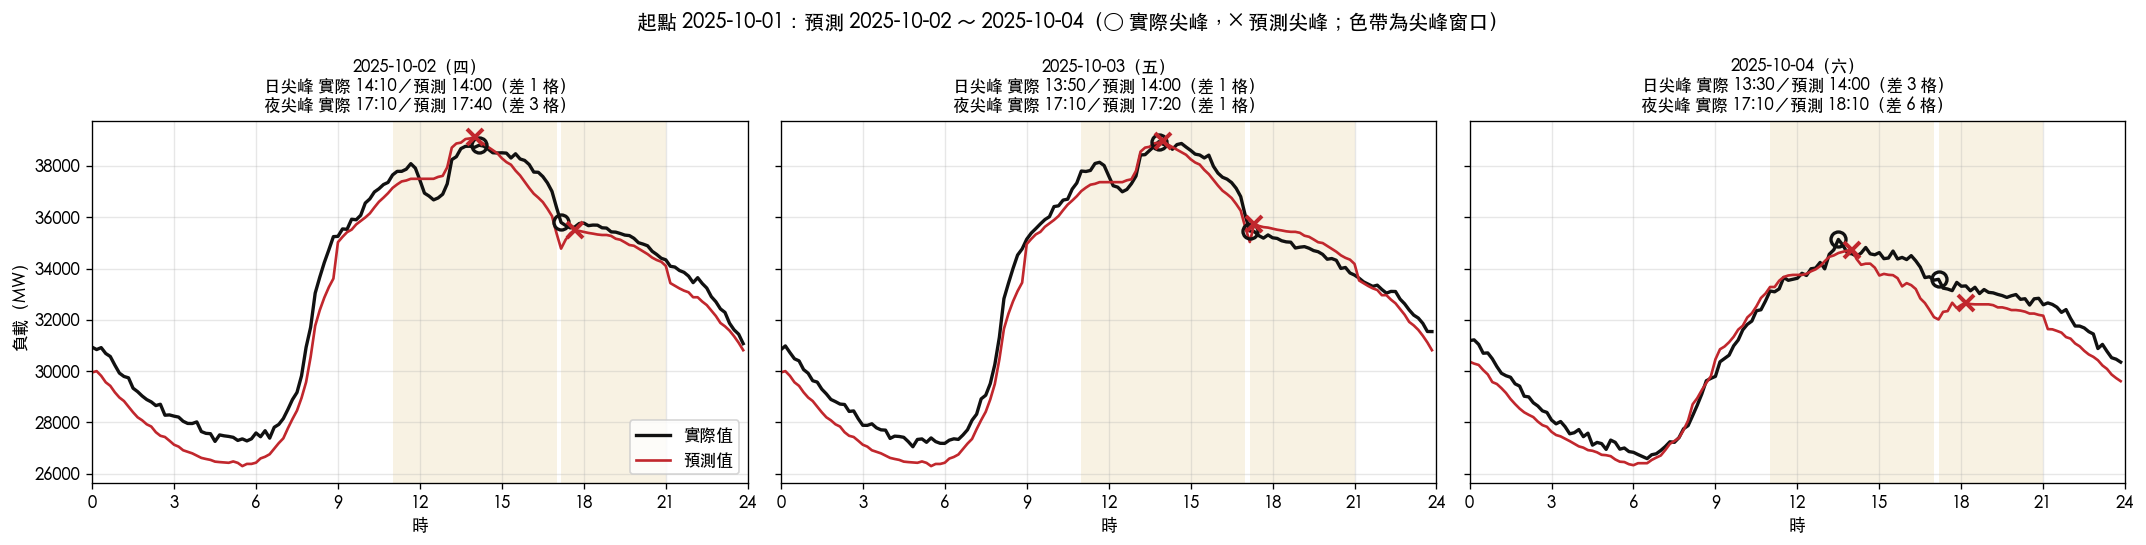

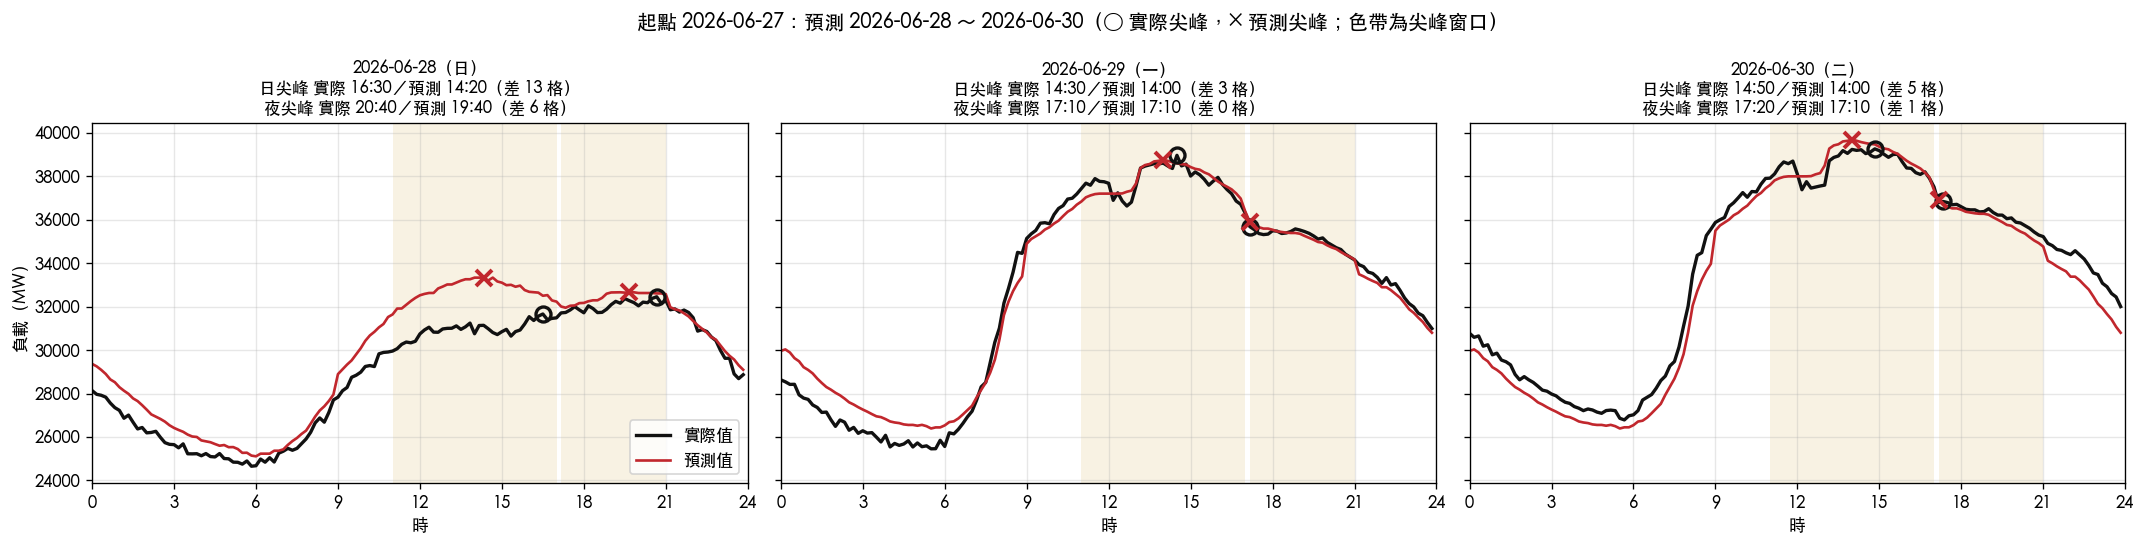

In [5]:
import datetime as dt
from IPython.display import Image
from src import workflow
from src.evaluation import plots

curves = pl.read_csv(run_dir / "curves.csv", try_parse_dates=True)
latest = workflow.predict_window(dt.date(2026, 6, 27)).with_columns(pl.col("ts").cast(curves.schema["ts"]))
paths.FIGURES_DIR.mkdir(parents=True, exist_ok=True)
for table, origin in ((curves, dt.date(2025, 10, 1)), (latest, dt.date(2026, 6, 27))):
    figure = plots.plot_window(table, origin, paths.FIGURES_DIR / f"curves_{origin:%Y%m%d}.png")
    display(Image(filename=str(figure), width=1300))

## 4. 432 點的 MAPE（參考用）

`MAPE = mean(|預測 − 實際| / 實際) × 100%`，一窗 432 點。**這不是模型的評估指標**：模型最佳化的是 6 個尖峰量，
尖峰之間的形狀取自歷史同組日的中位數形狀。列出來只是讓曲線整體的貼合程度有個數字。
參考值是「起點以前最近 4 個同星期日的逐點中位數」這條最簡單的曲線。

In [6]:
clean = pl.read_parquet(paths.CLEAN_LOAD_FILE)
all_curves = plots.same_weekday_curves(clean, pl.concat([curves, latest]))
mape = plots.curve_mape(all_curves).join(plots.curve_mape(all_curves, "same_weekday").rename({"mape": "參考"}), on="origin")
tuning = mape.filter(pl.col("origin").is_in(folds["origin"].to_list()))
season_mape = tuning.filter(pl.col("origin").is_in(groups["同季節"]))
rows = [("2025-10-02～04", mape.filter(pl.col("origin") == dt.date(2025, 10, 1))),
        ("2026-06-28～30", mape.filter(pl.col("origin") == dt.date(2026, 6, 27))),
        (f"調參組 {tuning.height} 窗平均", tuning), (f"同季節 {season_mape.height} 窗平均", season_mape)]
display(pl.DataFrame([{"範圍": name, "本模型 MAPE（%）": part["mape"].mean(), "參考曲線 MAPE（%）": part["參考"].mean()}
                      for name, part in rows]))
print(f"調參組逐窗 MAPE 中位數 {tuning['mape'].median():.2f}%，最小 {tuning['mape'].min():.2f}%，最大 {tuning['mape'].max():.2f}%")

範圍,本模型 MAPE（%）,參考曲線 MAPE（%）
str,f64,f64
"""2025-10-02～04""",1.863208,0.731167
"""2026-06-28～30""",2.237832,3.126733
"""調參組 78 窗平均""",3.173499,3.937716
"""同季節 21 窗平均""",2.499774,3.042498


調參組逐窗 MAPE 中位數 2.82%，最小 1.21%，最大 9.74%


## 5. 逐窗分數

依起點排序；紅色是同季節窗。冬季的窗分數明顯偏高，這也是為什麼選模時要另外看同季節子集。

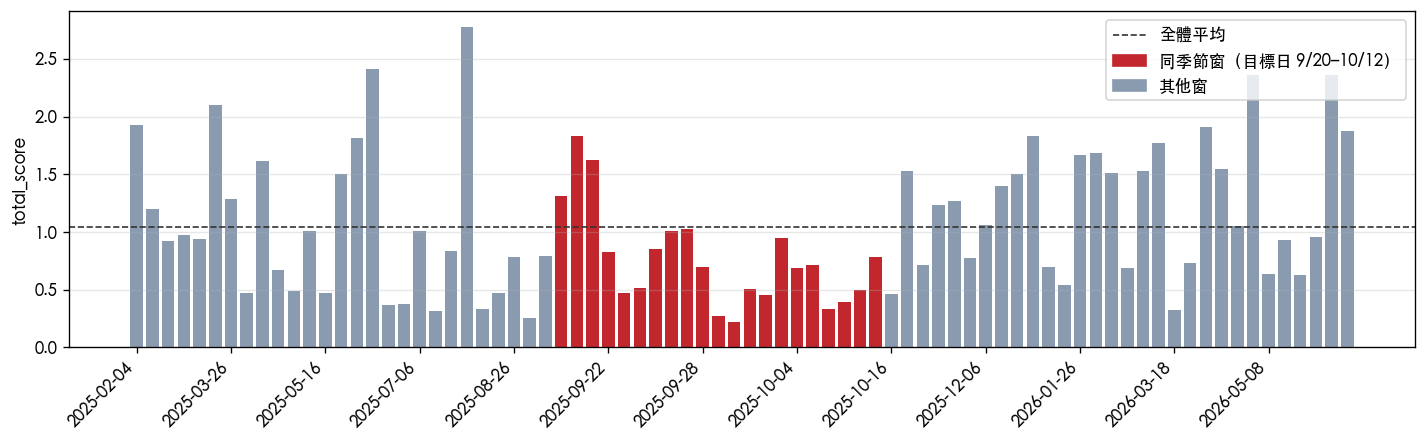

In [7]:
display(Image(filename=str(plots.plot_window_scores(folds, groups["同季節"], paths.FIGURES_DIR / "window_scores.png")), width=1100))

## 6. 尖峰時刻誤差（依子集與日別）

`s_peak_time` 是日、夜兩個時刻的平均；拆開看才知道是哪一個出問題。各窗的目標日會重疊，故以「起點→目標日」為單位。

In [8]:
loss = backtest.window_losses(predictions, actual.select("date", *TARGET_NAMES)).with_columns(
    pl.col("date").str.slice(0, 10).str.to_date().alias("origin"),
    pl.col("date").str.slice(-10).str.to_date().alias("target_date"))
in_season = pl.col("origin").is_in(groups["同季節"])
loss.with_columns(pl.when(in_season).then(pl.lit("同季節")).otherwise(pl.lit("其他")).alias("子集")).group_by("子集").agg(
    pl.len().alias("窗日數"), pl.col("t_day").mean(), pl.col("t_night").mean(),
    pl.col("p_day").mean(), pl.col("p_night").mean(), pl.col("ramp_up").mean(), pl.col("ramp_down").mean(),
).sort("子集")

子集,窗日數,t_day,t_night,p_day,p_night,ramp_up,ramp_down
str,u32,f64,f64,f64,f64,f64,f64
"""其他""",171,11.519432,2.815909,0.02665,0.021336,0.172048,0.147935
"""同季節""",63,3.994203,5.291016,0.028095,0.021464,0.177568,0.149705


In [9]:
loss.join(actual.select(pl.col("date").alias("target_date"), "price_daytype"), on="target_date").group_by("price_daytype").agg(
    pl.len().alias("窗日數"), pl.col("t_day").mean(), pl.col("t_night").mean(),
    pl.col("p_day").mean(), pl.col("p_night").mean(),
).sort("price_daytype")

price_daytype,窗日數,t_day,t_night,p_day,p_night
str,u32,f64,f64,f64,f64
"""平日""",154,10.836521,2.652951,0.030026,0.022689
"""週六""",33,7.49667,4.117269,0.023523,0.016564
"""週日及離峰日""",47,6.494538,5.753831,0.019718,0.020426


尖峰時刻誤差的分布（預測 − 實際，以格計）：直方圖以密度呈現，全體與同季節的天數不同。

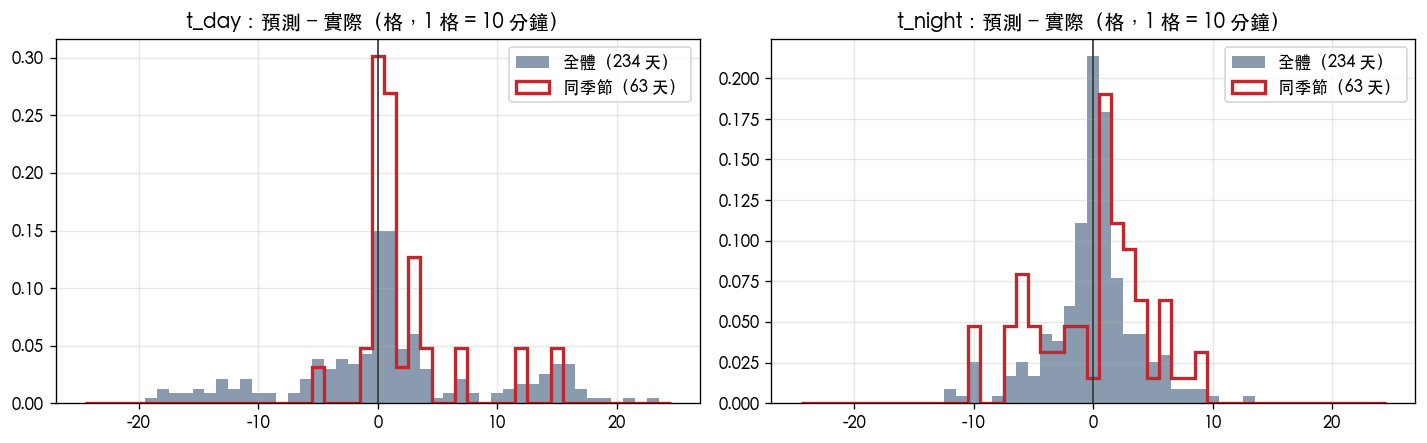

In [10]:
errors = plots.timing_errors(predictions, actual)
display(Image(filename=str(plots.plot_timing_errors(errors, groups["同季節"], paths.FIGURES_DIR / "timing_errors.png")), width=1100))

尖峰負載的預測對實際。分位數 τ = 0.625 的設計意圖是約 62.5% 的日子預測不低於實際；圖上標出實際比例。

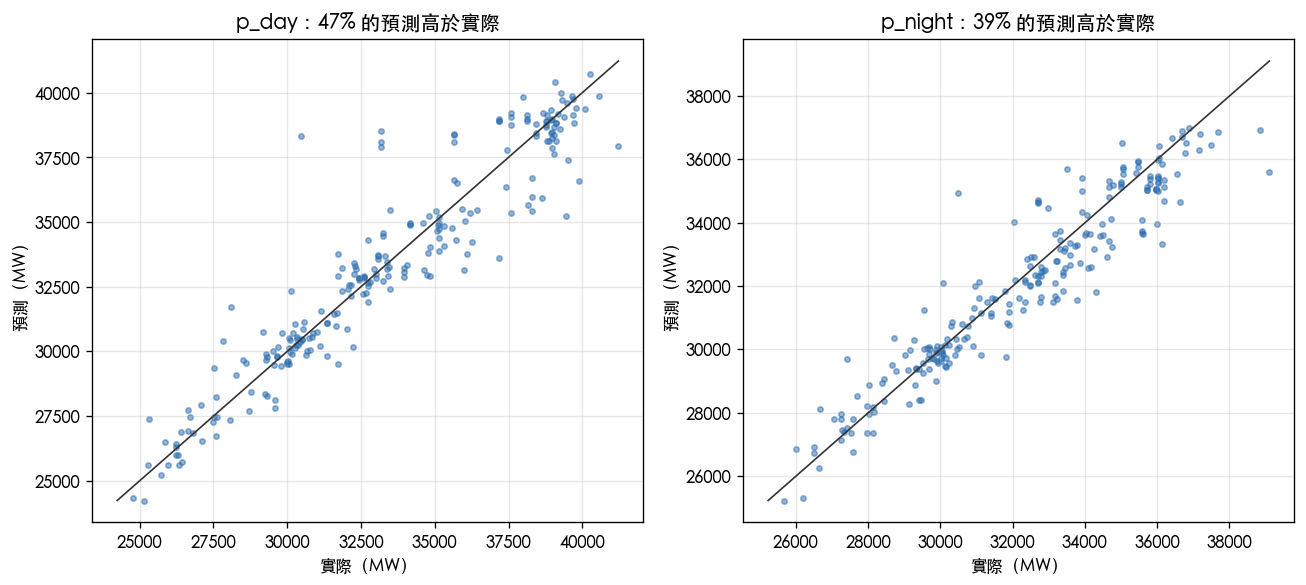

In [11]:
display(Image(filename=str(plots.plot_peak_scatter(predictions, actual, paths.FIGURES_DIR / "peak_scatter.png")), width=1000))

## 7. 預報與觀測的誤差（逐站、逐季）

「依領先時間分組的誤差分布」算不出來：Accuweather 沒有發布時間欄，每個目標時刻只有一個版本。
改列未校正預報與 CODiS 觀測在重疊期的誤差。

In [12]:
from src.data import external
from src.features import accuweather as accuweather_features

forecast = accuweather_features.build_forecast()
observed = external._load_weather_codis(fill=False)
display(accuweather_features.compare_with_observed(forecast, observed))
joined = forecast.join(observed, on="date", suffix="_obs")
season = {"夏月（5–10 月）": [5, 6, 7, 8, 9, 10], "9–10 月": [9, 10], "冬季（11–3 月）": [11, 12, 1, 2, 3]}
pl.DataFrame([
    {"站": column.split("_")[1], "期間": name,
     "平均絕對誤差": joined.filter(pl.col("date").dt.month().is_in(months))
         .select((pl.col(column) - pl.col(f"{column}_obs")).abs().mean()).item()}
    for column in forecast.columns if column.endswith("_day_tmax")
    for name, months in season.items()
]).pivot(on="期間", index="站", values="平均絕對誤差")

項目,n,r,bias,MAE
str,i64,f64,f64,f64
"""day_tmax""",4530,0.921687,0.974349,1.755673
"""day_tmin""",4530,0.954518,0.651523,1.386225
"""night_tmax""",4530,0.935904,0.598896,1.427903
"""night_tmin""",4530,0.935187,0.007373,1.471611
"""五站 day_tmax 最大值""",906,0.922081,1.168102,1.651325


站,夏月（5–10 月）,9–10 月,冬季（11–3 月）
str,f64,f64,f64
"""新北""",1.883765,1.772951,2.137596
"""臺北""",1.385882,1.086885,1.696164
"""臺南""",1.262824,1.309016,1.893862
"""高雄""",1.063529,0.87459,1.462404
"""臺中""",2.047529,2.654098,2.682864


## 8. 預報缺漏時的備援（Plan B）

相對完整預報的 total_score 增加量。「10/3 缺」「10/2–3 缺」由三天全缺的紀錄離線重組
（只替換那幾天的預測；每個目標日獨立評分，與直接執行完全一致）。
採用：整天缺 → 那幾天改用不含氣象的模型；部分城市缺 → 那些城市以最近一天的觀測補。

In [13]:
backtest.plan_b_table()

情境,名稱,total_score,差值,標準誤倍數,同季節差值,同季節標準誤倍數
str,str,f64,f64,f64,f64,f64
"""10/3 缺""","""不用氣象的模型""",1.071273,0.014979,1.344782,0.014067,1.705441
"""10/3 缺""","""最近一天的觀測""",1.08913,0.032836,2.623189,0.0219,1.207459
"""10/3 缺""","""同月氣候值""",1.092531,0.036237,3.131871,0.048727,2.5044
"""10/2–3 缺""","""不用氣象的模型""",1.084697,0.028404,1.998626,0.031635,2.410534
"""10/2–3 缺""","""最近一天的觀測""",1.106596,0.050302,2.47094,0.069814,1.41465
"""10/2–3 缺""","""同月氣候值""",1.121042,0.064748,3.888021,0.09637,3.730519
"""三天全缺""","""不用氣象的模型""",1.087295,0.031002,1.911301,0.040669,2.540022
"""三天全缺""","""最近一天的觀測""",1.113295,0.057001,2.078627,0.113297,1.458851
"""三天全缺""","""同月氣候值""",1.151608,0.095315,4.76943,0.140541,4.676367


## 9. Windy 的多種子確認

三個種子都改善、方向一致；同季節持平——改善來自其他季節，對 10/1–10/3 的預期效益接近 0。

In [14]:
backtest.seed_confirmation_table([(42, "4a_A1_noUV", "4c_windy"),
                                   (1337, "A1_seed1337", "4c_windy_seed1337"),
                                   (2718, "A1_seed2718", "4c_windy_seed2718")])

種子,參考,候選,差值,標準誤倍數,同季節差值,同季節標準誤倍數,通過門檻
str,f64,f64,f64,f64,f64,f64,bool
"""42""",1.064475,1.041693,-0.022781,1.810511,-0.000491,0.045915,true
"""1337""",1.068573,1.027018,-0.041555,3.073016,-0.001902,0.161894,true
"""2718""",1.072226,1.029534,-0.042692,2.944778,-0.000098,0.007812,true
"""平均""",1.068425,1.032748,-0.035676,2.904963,-0.000831,0.105786,true


## 10. 時刻損失拆在哪裡

全年看 `t_day` 是主因；**同季節反過來，`t_night` 比 `t_day` 大**——提交日的時刻誤差主要在夜尖峰。
horizon 之間差異很小。

In [15]:
timing = loss.with_columns(((pl.col("target_date") - pl.col("origin")).dt.total_days()).alias("horizon"))
display(timing.group_by("horizon").agg(pl.len().alias("窗日數"), pl.col("t_day").mean(), pl.col("t_night").mean()).sort("horizon"))
timing.with_columns(pl.col("origin").is_in(groups["同季節"]).alias("同季節")).group_by("同季節").agg(
    pl.len().alias("窗日數"), pl.col("t_day").mean(), pl.col("t_night").mean())

horizon,窗日數,t_day,t_night
i64,u32,f64,f64
1,78,9.364351,3.704309
2,78,9.630508,2.951055
3,78,9.485366,3.791488


同季節,窗日數,t_day,t_night
bool,u32,f64,f64
true,63,3.994203,5.291016
false,171,11.519432,2.815909


## 11. 換種子的雜訊

同一個設定只換隨機種子，配對差就可以到 1.16 個標準誤——所以通過門檻的候選還要以 3 個種子確認。

In [16]:
backtest.seed_confirmation_table([(1337, "4a_A1_noUV", "A1_seed1337"),
                                   (2718, "4a_A1_noUV", "A1_seed2718")]).drop("通過門檻")

種子,參考,候選,差值,標準誤倍數,同季節差值,同季節標準誤倍數
str,f64,f64,f64,f64,f64,f64
"""1337""",1.064475,1.068573,0.004098,0.584573,0.015433,1.256
"""2718""",1.064475,1.072226,0.007751,1.159447,0.004011,0.337752
"""平均""",1.064475,1.070399,0.005925,1.015248,0.009722,0.931005


## 12. 以主辦單位計分程式複核

`organizer_score.py` 只用 Python 標準函式庫、不 import 專案程式，依比賽規則獨立重寫了
「由 144 點推導 6 個量」（窗口內並列取最早）與評分公式。這裡用它把 04 的回測紀錄全部重算一次：

- 預測曲線推導出的 6 個量，必須等於合成後實現的值（`predictions.csv`）
- 與模型原始輸出（`raw_targets.csv`）相比，只允許合成時放寬的 `ramp_up`／`ramp_down` 不同
- 實際曲線推導出的 6 個量，必須等於標籤（`targets.parquet`）
- 逐窗的 5 個子項與 total_score，必須等於 `folds.csv`

同一套檢查可用 `python main.py verify-curves` 執行。

In [17]:
from src.evaluation import verify

check = verify.verify_run(run_dir)
print("全部一致" if check["ok"] else "有不一致")
display(check["checks"])
if check["repairs"] is not None:
    display(check["repairs"])
if check["mismatches"] is not None:
    display(check["mismatches"])

全部一致


比對,筆數,不一致,最大差異
str,i64,i64,f64
"""合成實現的 6 個量""",1404,0,0.0
"""模型原始的 6 個量""",1404,0,0.000001
"""實際值的 6 個量""",1404,0,0.0
"""逐窗子項與 total_score""",468,0,3.5527e-15
"""全體平均""",6,0,8.8818e-16


## 13. 保留確認組（2026 年 7–9 月）

只在選定最終設定後使用一次（`python main.py backtest --group holdout --label <名稱> --confirm-holdout`），
本 notebook 只讀取已存在的紀錄，不會去跑它。

In [18]:
holdout_runs = sorted(paths.BACKTEST_DIR.glob("*_holdout"))
if not holdout_runs:
    print("尚未執行：保留確認組需要 2024-01-01 ~ 2026-09-30 的負載檔，並在選定最終設定後才跑。")
else:
    rows = []
    for folder in holdout_runs:
        s = json.loads((folder / "summary.json").read_text(encoding="utf-8"))
        rows.append({"紀錄": folder.name, "label": s["label"], "窗數": s["n_windows"],
                     "略過": len(s["skipped"]), **{k: v for k, v in s["overall"].items() if k != "n"}})
    display(pl.DataFrame(rows))

尚未執行：保留確認組需要 2024-01-01 ~ 2026-09-30 的負載檔，並在選定最終設定後才跑。
